#<font color="blue"><b>----- Multi-Task PLM Fine-Tuning -----</b></font>

### <font color="purple"><b>Problem Statement: Multi-Task PLM Fine-Tuning</b></font>

In this demo, we will build a **multi-task fine-tuning system** using **DistilBERT** as a shared pretrained language encoder. The model will be trained simultaneously on four NLP tasks:

- **SST-2** – Sentiment Classification
- **AG News** – Topic Classification
- **CoLA** – Grammatical Acceptability Classification
- **STS-B** – Semantic Textual Similarity Regression

The objective is to understand how a **single shared language model can learn multiple NLP tasks** by using a separate task-specific prediction head for each task.

Steps:

1. Load and prepare the four datasets using a common task registry.
2. Tokenize the text using the DistilBERT tokenizer with truncation and padding.
3. Create separate datasets and data loaders for each task.
4. Build a multi-task model with a **shared DistilBERT encoder** and **one task-specific head per task**.
5. Train the model using a **round-robin multi-task training strategy**, where batches from different tasks are processed alternately.
6. Use **Cross-Entropy Loss** for classification tasks and **Mean Squared Error (MSE) Loss** for the regression task.
7. Save the fine-tuned model as a checkpoint and load it if a checkpoint already exists.
8. Randomly select **five test samples from each task** and compare the model's predictions with the true labels or similarity scores.

### <font color="purple">**Overall Flow is as follows:**</font>

<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/Multi_Task_FFT.png" width="900">

In [ ]:
##-------------START------------------------##

### <font color="blue"><b>Import Required Packages</b></font>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from datasets import load_dataset

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
SEED = 42
set_seed(SEED)

### <font color="blue"><b>Configurations</b></font>

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3                 # bump up for real training
TRAIN_SUBSET = 2000        # examples per task used for training (demo speed)
EVAL_SUBSET = 200          # examples per task used for quick eval
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "multitask_distilbert_finetuned.pt"  # where the fine-tuned weights are saved/loaded

### <font color="blue"><b>Task registry</b></font>

In [ ]:
def load_sst2():
    ds = load_dataset("nyu-mll/glue", "sst2")
    train = ds["train"].shuffle(seed=SEED).select(range(TRAIN_SUBSET))
    test = ds["validation"].shuffle(seed=SEED).select(range(EVAL_SUBSET))
    return (train["sentence"], train["label"],
            test["sentence"], test["label"])

def load_agnews():
    ds = load_dataset("wangrongsheng/ag_news")
    train = ds["train"].shuffle(seed=SEED).select(range(TRAIN_SUBSET))
    test = ds["test"].shuffle(seed=SEED).select(range(EVAL_SUBSET))
    return (train["text"], train["label"],
            test["text"], test["label"])

def load_cola():
    ds = load_dataset("nyu-mll/glue", "cola")
    n_train = min(TRAIN_SUBSET, len(ds["train"]))
    n_eval = min(EVAL_SUBSET, len(ds["validation"]))
    train = ds["train"].shuffle(seed=SEED).select(range(n_train))
    test = ds["validation"].shuffle(seed=SEED).select(range(n_eval))
    return (train["sentence"], train["label"],
            test["sentence"], test["label"])

def load_stsb():
    ds = load_dataset("nyu-mll/glue", "stsb")
    n_train = min(TRAIN_SUBSET, len(ds["train"]))
    n_eval = min(EVAL_SUBSET, len(ds["validation"]))
    train = ds["train"].shuffle(seed=SEED).select(range(n_train))
    test = ds["validation"].shuffle(seed=SEED).select(range(n_eval))
    # STS-B has sentence1 / sentence2 pairs; join them for a single-text input
    train_texts = [f"{a} [SEP] {b}" for a, b in zip(train["sentence1"], train["sentence2"])]
    test_texts = [f"{a} [SEP] {b}" for a, b in zip(test["sentence1"], test["sentence2"])]
    return (train_texts, train["label"], test_texts, test["label"])


TASKS = [
    {"name": "sst2",   "type": "cls", "num_labels": 2, "loader": load_sst2,
     "label_names": ["negative", "positive"]},
    {"name": "agnews", "type": "cls", "num_labels": 4, "loader": load_agnews,
     "label_names": ["World", "Sports", "Business", "Sci/Tech"]},
    {"name": "cola",   "type": "cls", "num_labels": 2, "loader": load_cola,
     "label_names": ["unacceptable", "acceptable"]},
    {"name": "stsb",   "type": "reg", "num_labels": 1, "loader": load_stsb,
     "label_names": None},
]

In [ ]:
tr_x, tr_y, te_x, te_y = load_sst2()
names = ["negative", "positive"]
print("TASK: sst2 (cls, 2 labels)")
for i in range(5):
    print(f"\n[{i+1}] label: {tr_y[i]} ({names[tr_y[i]]})")
    print(f"    text : {tr_x[i][:300]}")

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

TASK: sst2 (cls, 2 labels)

[1] label: 1 (positive)
    text : klein , charming in comedies like american pie and dead-on in election , 

[2] label: 1 (positive)
    text : be fruitful 

[3] label: 1 (positive)
    text : soulful and 

[4] label: 1 (positive)
    text : the proud warrior that still lingers in the souls of these characters 

[5] label: 0 (negative)
    text : covered earlier and much better 


In [ ]:
tr_x, tr_y, te_x, te_y = load_agnews()
names = ["World", "Sports", "Business", "Sci/Tech"]
print("TASK: agnews (cls, 4 labels)")
for i in range(5):
    print(f"\n[{i+1}] label: {tr_y[i]} ({names[tr_y[i]]})")
    print(f"    text : {tr_x[i][:300]}")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

TASK: agnews (cls, 4 labels)

[1] label: 0 (World)
    text : Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.

[2] label: 1 (Sports)
    text : Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington.

[3] label: 0 (World)
    text : Will Putin #39;s Power Play Make Russia Safer? Outwardly, Russia has not changed since the barrage of terrorist attacks that culminated in the school massacre in Beslan on Sept.

[4] label: 3 (Sci/Tech)
    text : U2 pitches for Apple New iTunes ads airing during baseball games Tuesday will feature the advertising-shy Irish rockers.

[5] label: 0 (World)
    text : S African TV in beheading blunder Public broadcaster SABC apologises after news bulletin shows footage of American beheaded in Iraq.


In [ ]:
tr_x, tr_y, te_x, te_y = load_cola()
names = ["unacceptable", "acceptable"]
print("TASK: cola (cls, 2 labels)")
for i in range(5):
    print(f"\n[{i+1}] label: {tr_y[i]} ({names[tr_y[i]]})")
    print(f"    text : {tr_x[i][:300]}")

cola/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  251kB            

cola/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

cola/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 37.6kB            

cola/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

cola/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 37.7kB            

cola/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]

TASK: cola (cls, 2 labels)

[1] label: 0 (unacceptable)
    text : Sodium is a little too peppy for me to want to try mixing and water in a teacup.

[2] label: 0 (unacceptable)
    text : I am having eaten seaweed.

[3] label: 0 (unacceptable)
    text : She's enough tall.

[4] label: 1 (acceptable)
    text : Sandy sang me a song.

[5] label: 1 (acceptable)
    text : I know I should go to the dentist's, but I just don't want to.


In [ ]:
tr_x, tr_y, te_x, te_y = load_stsb()
print("TASK: stsb (reg, similarity score)")
for i in range(5):
    print(f"\n[{i+1}] score: {tr_y[i]:.2f}")
    print(f"    text : {tr_x[i][:300]}")

stsb/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  502kB            

stsb/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

stsb/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  151kB            

stsb/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

stsb/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  114kB            

stsb/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

TASK: stsb (reg, similarity score)

[1] score: 0.20
    text : Five killed in China building collapse [SEP] At least 20 killed in Syria Saturday

[2] score: 1.00
    text : Factories that ran on Korean cooperation go silent [SEP] North and South Korea break their silence with talks

[3] score: 4.80
    text : Seamus Heaney, Irish Poet of Soil and Strife, Dies at 74 [SEP] Seamus Heaney, Irish poet and Nobel winner, dies at 74

[4] score: 0.64
    text : A woman is speaking in sign language. [SEP] A woman spices some seafood.

[5] score: 4.60
    text : On the upside, Coca-Cola Co. (nyse: KO - news - people) reported higher profit for the quarter early on Thursday, helped by European demand. [SEP] Coca-Cola Co. (KO) reported higher profit for the quarter, helped by European demand, early on Thursday.


### <font color="blue"><b>Multi-Task Dataset creation</b></font>

In [ ]:
class TaskDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, task_type):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.task_type = task_type

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.task_type == "reg":
            item["labels"] = torch.tensor(float(self.labels[idx]), dtype=torch.float)
        else:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

In [ ]:
def make_loader(dataset, shuffle):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)

### <font color="blue"><b>Model Class</b></font>

In [ ]:
class MultiTaskDistilBert(nn.Module):
    """Shared DistilBERT encoder + one linear head per task."""

    def __init__(self, model_name, tasks):
        super().__init__()
        self.encoder = DistilBertModel.from_pretrained(model_name)
        hidden = self.encoder.config.dim
        self.dropout = nn.Dropout(0.1)
        self.heads = nn.ModuleDict({
            t["name"]: nn.Linear(hidden, t["num_labels"]) for t in tasks
        })

    def forward(self, input_ids, attention_mask, task_name):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # DistilBERT has no pooler; use [CLS] token (first token) hidden state
        cls_repr = out.last_hidden_state[:, 0]
        cls_repr = self.dropout(cls_repr)
        logits = self.heads[task_name](cls_repr)
        return logits

### <font color="blue"><b>Train and Predict Functions</b></font>

In [ ]:
def train_multitask(model, task_loaders, epochs):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    cls_loss_fn = nn.CrossEntropyLoss()
    reg_loss_fn = nn.MSELoss()

    # history[task_name] = [mean_loss_epoch0, mean_loss_epoch1, ...]
    history = {name: [] for name in task_loaders}

    for epoch in range(epochs):
        model.train()
        loss_sum = {name: 0.0 for name in task_loaders}
        n_steps  = {name: 0   for name in task_loaders}

        # Round-robin over tasks so each batch trains a different task
        iterators = {name: iter(dl) for name, dl in task_loaders.items()}
        active = list(iterators.keys())
        while active:
            for name in list(active):
                try:
                    batch = next(iterators[name])
                except StopIteration:
                    active.remove(name)
                    continue

                task_type = next(t["type"] for t in TASKS if t["name"] == name)
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["labels"].to(DEVICE)

                logits = model(input_ids, attention_mask, name)
                if task_type == "reg":
                    loss = reg_loss_fn(logits.squeeze(-1), labels)
                else:
                    loss = cls_loss_fn(logits, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                loss_sum[name] += loss.item()
                n_steps[name]  += 1

        # Mean loss per task for this epoch
        for name in task_loaders:
            history[name].append(loss_sum[name] / max(n_steps[name], 1))
        print(f"epoch {epoch}: " +
              " | ".join(f"{n}={history[n][-1]:.4f}" for n in task_loaders))

    return history

In [ ]:
@torch.no_grad()
def predict(model, text, tokenizer, task):
    model.eval()
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)
    logits = model(input_ids, attention_mask, task["name"])
    if task["type"] == "reg":
        return round(logits.item(), 3)
    else:
        pred_idx = logits.argmax(dim=-1).item()
        return task["label_names"][pred_idx]

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
model = MultiTaskDistilBert(MODEL_NAME, TASKS).to(DEVICE)

task_loaders = {}
val_loaders = {}
task_test_data = {}  # keep raw text/labels for the demo section

print("Loading datasets...")
for task in TASKS:
    train_texts, train_labels, test_texts, test_labels = task["loader"]()
    train_ds = TaskDataset(train_texts, train_labels, tokenizer, task["type"])
    val_ds   = TaskDataset(test_texts,  test_labels,  tokenizer, task["type"])
    task_loaders[task["name"]] = make_loader(train_ds, shuffle=True)
    val_loaders[task["name"]]  = make_loader(val_ds,   shuffle=False)
    task_test_data[task["name"]] = (list(test_texts), list(test_labels))
    print(f"  {task['name']}: {len(train_texts)} train / {len(test_texts)} test examples")

history = None
if os.path.exists(CHECKPOINT_PATH):
    print(f"\nFound existing fine-tuned checkpoint at '{CHECKPOINT_PATH}' — loading it (skipping training).")
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.to(DEVICE)
else:
    print("\nNo fine-tuned checkpoint found — training from the pretrained base model...")
    history = train_multitask(model, task_loaders, EPOCHS)
    torch.save(model.state_dict(), CHECKPOINT_PATH)
    print(f"Saved fine-tuned weights to '{CHECKPOINT_PATH}'.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading datasets...
  sst2: 2000 train / 200 test examples
  agnews: 2000 train / 200 test examples
  cola: 2000 train / 200 test examples
  stsb: 2000 train / 200 test examples

No fine-tuned checkpoint found — training from the pretrained base model...
epoch 0: sst2=0.4856 | agnews=0.6393 | cola=0.6066 | stsb=1.3528
epoch 1: sst2=0.2543 | agnews=0.2993 | cola=0.5325 | stsb=0.5097
epoch 2: sst2=0.1117 | agnews=0.1759 | cola=0.4054 | stsb=0.2899
Saved fine-tuned weights to 'multitask_distilbert_finetuned.pt'.


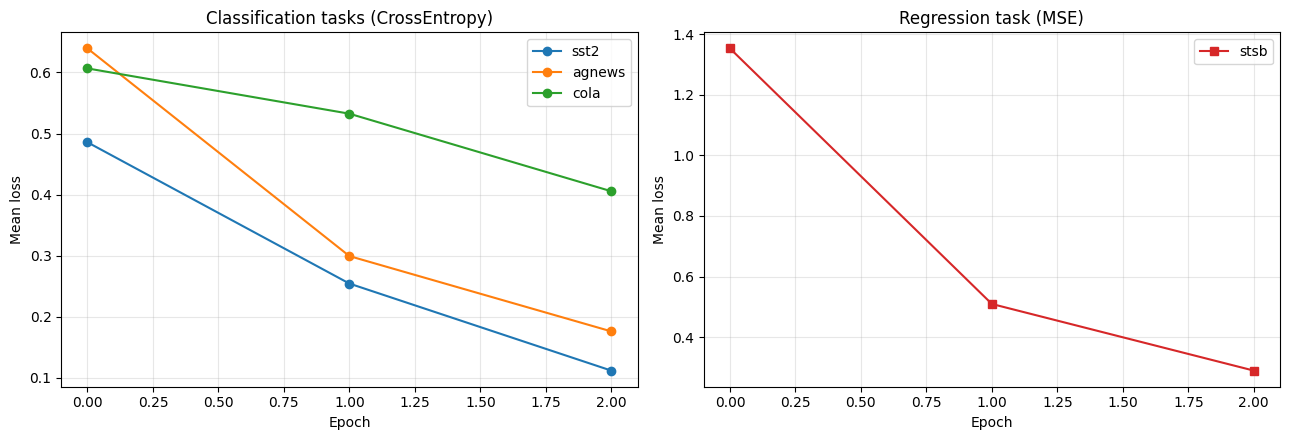

In [ ]:
if history is None:
    print("Loaded from checkpoint — no training history to plot. ")
else:
    cls_tasks = [t["name"] for t in TASKS if t["type"] == "cls"]
    reg_tasks = [t["name"] for t in TASKS if t["type"] == "reg"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Classification tasks (cross-entropy)
    for name in cls_tasks:
        axes[0].plot(range(len(history[name])), history[name], marker="o", label=name)
    axes[0].set_title("Classification tasks (CrossEntropy)")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Mean loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Regression task (MSE)
    for name in reg_tasks:
        axes[1].plot(range(len(history[name])), history[name], marker="s",
                     color="tab:red", label=name)
    axes[1].set_title("Regression task (MSE)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Mean loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
@torch.no_grad()
def evaluate_multitask(model, val_loaders):
    model.eval()
    for name, dl in val_loaders.items():
        task = next(t for t in TASKS if t["name"] == name)
        preds, golds = [], []

        for batch in dl:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"]

            logits = model(input_ids, attention_mask, name)
            if task["type"] == "reg":
                preds.extend(logits.squeeze(-1).cpu().numpy().tolist())
            else:
                preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
            golds.extend(labels.numpy().tolist())

        print("=" * 70)
        print(f"TASK: {name}  ({task['type']})")
        print("=" * 70)
        if task["type"] == "reg":
            rmse = np.sqrt(mean_squared_error(golds, preds))
            print(f"RMSE: {rmse:.4f}\n")
        else:
            print(classification_report(
                golds, preds,
                target_names=task["label_names"],
                digits=4, zero_division=0,
            ))

evaluate_multitask(model, val_loaders)

TASK: sst2  (cls)
              precision    recall  f1-score   support

    negative     0.9324    0.7419    0.8263        93
    positive     0.8095    0.9533    0.8755       107

    accuracy                         0.8550       200
   macro avg     0.8710    0.8476    0.8509       200
weighted avg     0.8667    0.8550    0.8527       200

TASK: agnews  (cls)
              precision    recall  f1-score   support

       World     0.9512    0.7800    0.8571        50
      Sports     0.9615    0.9615    0.9615        52
    Business     0.8491    0.8333    0.8411        54
    Sci/Tech     0.7593    0.9318    0.8367        44

    accuracy                         0.8750       200
   macro avg     0.8803    0.8767    0.8741       200
weighted avg     0.8841    0.8750    0.8755       200

TASK: cola  (cls)
              precision    recall  f1-score   support

unacceptable     0.7692    0.3279    0.4598        61
  acceptable     0.7644    0.9568    0.8498       139

    accuracy      

In [ ]:
def demo_task(task_name, n_samples=5):
    task = next(t for t in TASKS if t["name"] == task_name)
    texts, labels = task_test_data[task_name]
    print(f"--- Task: {task['name']} ---")
    idxs = random.sample(range(len(texts)), min(n_samples, len(texts)))
    for i in idxs:
        text = texts[i]
        true_label = labels[i]
        pred = predict(model, text, tokenizer, task)
        if task["type"] != "reg":
            true_label = task["label_names"][true_label]
        print(f"  text: {text}")
        print(f"    true: {true_label}   pred: {pred}\n")

In [ ]:
demo_task("sst2", n_samples=2)

--- Task: sst2 ---
  text: the chateau cleverly probes the cross-cultural differences between gauls and yanks . 
    true: positive   pred: positive

  text: samira makhmalbaf 's new film blackboards is much like the ethos of a stream of consciousness , although , it 's unfortunate for the viewer that the thoughts and reflections coming through are torpid and banal 
    true: negative   pred: negative



In [ ]:
demo_task("agnews", n_samples=3)

--- Task: agnews ---
  text: ADV: Try Currency Trading Risk-Free 30 Days 24-hour commission-free trading, 100-to-1 leverage of your capital, and Dealbook Fx 2 - our free advanced trading software. Sign up for our free 30-day trial and receive one-on-one training.
    true: Business   pred: Business

  text: Eurostocks Nudge Up on Ericsson  PARIS (Reuters) - European shares nosed up on Wednesday as  Ericsson gained on news it had won part of \$4-billion Cingular  deal and with Glaxo buoyed after Pfizer affirmed its outlook.
    true: Business   pred: Business

  text: Bush won #39;t take Iran #39;s word for it CRAWFORD, Texas As President Bush sees it,  quot;the only good deal is one that #39;s verifiable. quot;. He #39;s applauding the efforts of some European countries to get Iran to honor its commitment to refrain from developing nuclear weapons.
    true: World   pred: World



In [ ]:
demo_task("cola", n_samples=3)

--- Task: cola ---
  text: Kim put in the box.
    true: unacceptable   pred: unacceptable

  text: She can run an accelerator.
    true: acceptable   pred: acceptable

  text: That Fido barks annoys me.
    true: acceptable   pred: acceptable



In [ ]:
demo_task("stsb", n_samples=2)

--- Task: stsb ---
  text: A man is playing a flute. [SEP] A man is playing guitar.
    true: 2.1670000553131104   pred: 1.836

  text: A man is playing a flute. [SEP] A dog is barking at a fly.
    true: 0.0   pred: -0.169



### <font color="purple"><b> Summary: Multi-Task PLM Fine-Tuning</b></font>

- **Multi-task fine-tuning** uses a **single pretrained language model** to learn multiple NLP tasks.
- In this exercise, **DistilBERT** is used as the **shared encoder**.
- Four tasks are handled:
  - **SST-2** → Sentiment Classification
  - **AG News** → Topic Classification
  - **CoLA** → Grammatical Acceptability Classification
  - **STS-B** → Semantic Textual Similarity Regression
- The model has:
  - **One shared DistilBERT encoder** for learning common language representations.
  - **A separate task-specific prediction head** for each task.
- Training uses a **round-robin strategy**, where batches from different tasks are processed alternately.
- **Cross-Entropy Loss** is used for classification tasks.
- **MSE Loss** is used for the regression task.
- The fine-tuned model is saved as a **checkpoint** and can be loaded later.
- **Training loss curves** are used to observe optimization during training.
- **Model performance** should be evaluated separately using:
  - **Classification report** for SST-2, AG News, and CoLA.
  - **RMSE** for STS-B.
- Finally, five test samples from each task are used to compare **predictions with the true values**.

### <font color="purple"><b> Future Directions </b></font>

- **Use larger training datasets** to improve the model's ability to learn from diverse examples.
- **Evaluate on more diverse and unseen tasks** to test how well the shared encoder generalizes.
- **Experiment with different pretrained language models** such as BERT, RoBERTa, or DeBERTa.
- **Explore different multi-task training strategies**, including task sampling and loss weighting.
- **Compare different task-specific architectures** to determine which prediction heads work best for different tasks.
- **Use more comprehensive evaluation metrics** to better assess performance across classification and regression tasks.
- **Investigate task interference and positive transfer** to understand when learning multiple tasks helps or hurts individual task performance.

In [ ]:
##-------------END------------------------##